# State, Nodes, and Edges [Step 2 - Core Primitives]

> **MLCourse - Agentic AI - LangGraph**

This notebook covers the three building blocks of every LangGraph
application: **State** (TypedDict), **Nodes** (functions), and
**Edges** (connections including START/END). We build a 3-node
linear graph and visualize it.

In [1]:
# Import core libraries
import os                          # Environment variable access
from typing import TypedDict       # State schema definition
from dotenv import load_dotenv     # Load API keys from .env

load_dotenv()                      # Initialize .env loading

False

In [2]:
# API key guard -- ChatOllama is local, so always green
api_key = os.environ.get("OPENAI_API_KEY", "")
if api_key:
    print("[GREEN] API key found")
else:
    print("[GREEN] No API key needed -- using local ChatOllama")

[GREEN] No API key needed -- using local ChatOllama


In [3]:
# ## Part 1: Defining State with TypedDict
# State is the single shared data structure that flows through the graph.
# Every node reads from it and returns a partial update to it.
# TypedDict gives us static type checking and a clear data contract.

from typing_extensions import TypedDict as ExtTypedDict  # Runtime-compatible TypedDict

class ArticleState(TypedDict):
    topic: str                     # The input topic to write about
    draft: str                     # The first draft of the article
    polished: str                  # The final polished version

print("State schema defined:")
print("  topic: str   -- input topic")
print("  draft: str   -- first draft")
print("  polished: str -- final version")

State schema defined:
  topic: str   -- input topic
  draft: str   -- first draft
  polished: str -- final version


In [4]:
# ## Part 2: Writing Nodes
# A node is a plain Python function with this signature:
#   def node_name(state: StateSchema) -> dict
#
# The function receives the full current state and must return a dict
# containing only the fields it wants to update. LangGraph merges
# the returned dict into the state (partial update pattern).

from langchain_ollama import ChatOllama   # Local LLM for node logic
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(model="llama3.1:8b", temperature=0)

def write_draft(state: ArticleState) -> dict:
    """Node 1: Write a first draft about the topic."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Write a short 2-paragraph article draft. Be concise."),
        ("user", "Topic: {topic}")
    ])
    response = (prompt | llm).invoke({"topic": state["topic"]})
    return {"draft": response.content}     # Update only 'draft'

def polish(state: ArticleState) -> dict:
    """Node 2: Polish the draft into a final version."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Polish this draft. Fix grammar, improve flow. Keep it short."),
        ("user", "{draft}")
    ])
    response = (prompt | llm).invoke({"draft": state["draft"]})
    return {"polished": response.content}  # Update only 'polished'

def summarize(state: ArticleState) -> dict:
    """Node 3: Summarize the polished article in one sentence."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Summarize the following text in exactly one sentence."),
        ("user", "{polished}")
    ])
    response = (prompt | llm).invoke({"polished": state["polished"]})
    return {"polished": response.content}  # Overwrite polished with summary

print("Three nodes defined: write_draft, polish, summarize")

Three nodes defined: write_draft, polish, summarize


In [5]:
# ## Part 3: Building the Graph
# We wire nodes together using edges. The graph builder pattern is:
#   1. Create StateGraph with the state schema
#   2. Add nodes with add_node("name", function)
#   3. Add edges with add_edge(from_node, to_node)
#   4. Connect START and END to define entry/exit points
#   5. Compile to freeze the graph into a runnable

from langgraph.graph import StateGraph, START, END

# Create the graph with our ArticleState schema
graph = StateGraph(ArticleState)

# Register nodes -- each gets a string name and a callable
graph.add_node("write_draft", write_draft)     # Node 1
graph.add_node("polish", polish)               # Node 2
graph.add_node("summarize", summarize)          # Node 3

# Wire the edges -- this defines the control flow
graph.add_edge(START, "write_draft")            # Entry -> write_draft
graph.add_edge("write_draft", "polish")         # write_draft -> polish
graph.add_edge("polish", "summarize")           # polish -> summarize
graph.add_edge("summarize", END)                # summarize -> Exit

# Compile the graph -- locks in the structure
app = graph.compile()

print("Graph compiled successfully.")
print("Control flow: START -> write_draft -> polish -> summarize -> END")

Graph compiled successfully.
Control flow: START -> write_draft -> polish -> summarize -> END


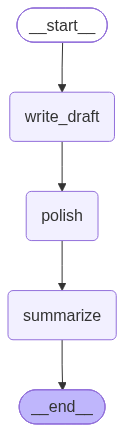

In [6]:
# ## Part 4: Visualize the Graph
# LangGraph can render the graph structure as a Mermaid diagram.
# This is invaluable for debugging and documentation.

from IPython.display import Image, display

try:
    # Render the graph as a PNG image via Mermaid
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Graceful fallback if Mermaid/Internet is unavailable
    print("Graph structure:")
    print("  START --> write_draft --> polish --> summarize --> END")

In [7]:
# ## Part 5: Invoke the Graph
# Invocation follows the same pattern as chains: provide initial state
# and get back the final state after all nodes have run.

initial_state = {
    "topic": "The benefits of local LLMs",
    "draft": "",
    "polished": ""
}

final_state = app.invoke(initial_state)

print("=== Final State ===")
print("Topic:", final_state["topic"])
print()
print("Draft (first 200 chars):")
print(final_state["draft"][:200])
print()
print("Polished (first 200 chars):")
print(final_state["polished"][:200])

=== Final State ===
Topic: The benefits of local LLMs

Draft (first 200 chars):
Here is a 2-paragraph article draft on the benefits of local Large Language Models (LLMs):

As technology continues to advance, the use of Large Language Models (LLMs) has become increasingly prevalen

Polished (first 200 chars):
Here is a summary of the text in exactly one sentence:

The use of local Large Language Models offers several advantages, including improved security, reduced latency, and enhanced performance, making


In [8]:
# ## Part 6: Key Concepts Recap
#
# **State (TypedDict)**
# - Defines the shape of data flowing through the graph
# - Every field is optional in updates (partial update pattern)
# - TypedDict gives type safety and IDE support
#
# **Nodes (functions)**
# - Receive full state, return dict of field updates
# - Side effects (LLM calls, file I/O) happen inside nodes
# - Nodes are the only place where work happens
#
# **Edges (connections)**
# - `add_edge(A, B)` means: after A finishes, run B next
# - `add_edge(START, X)` marks X as the entry node
# - `add_edge(X, END)` marks X as an exit node
# - Linear edges: START -> N1 -> N2 -> N3 -> END
#
# **Compile + Invoke**
# - `compile()` freezes the graph into a runnable object
# - `invoke(state)` executes the graph from START to END
# - The returned dict is the final state

print("Core primitives mastered: State, Nodes, Edges, Compile, Invoke.")

Core primitives mastered: State, Nodes, Edges, Compile, Invoke.
